In [11]:
from manipulateDFfns import merging2onedf
from AT_plots import polarPlot_largeDF, cart2pola


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.stats as astro
import scipy

In [3]:
antTrackDF = pd.read_csv("AbbottsWoodsCombinedTidy.csv")


#polarPlot_largeDF(antTrackDF)

/tmp/ipykernel_43266/2013556206.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  antTrackDF = pd.read_csv("AbbottsWoodsCombinedTidy.csv")


In [4]:
antTrackDF.head()

,Date,ID,frame,x,y,Nest,Condition
0,Jul-18,286,0,9.996429,15.959446,Wigwam,On-route 1 ZV
1,Jul-18,286,1,10.018027,15.991669,Wigwam,On-route 1 ZV
2,Jul-18,286,2,9.978276,15.939924,Wigwam,On-route 1 ZV
3,Jul-18,286,3,9.837419,16.045487,Wigwam,On-route 1 ZV
4,Jul-18,286,4,9.832482,16.051758,Wigwam,On-route 1 ZV


'Eye-capped off-route 1' 
'Eye-capped on-route 1' 
'Minus 3m ZV'
 'Off-route 1 ZV
  'On-route 1 ZV'
  'On-route 1B ZV
  'On-route 2 ZV'
 'Plus 3m Z
 ' 'Route 0m Z
 ' 'Unfamiliar FV
 ' 'Unfamiliar ZV'
 'Unfamiliar ZV 
 2' 'Unfamiliar ZV3']

/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/AT_plots.py:122: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/AT_plots.py:123: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 291 frames    Slowest Ant: 9296 frames
Fastest Ant: 11.64 seconds    Slowest Ant: 371.84 seconds
Eye-capped off-route 1
number of frames:  671
final headings:  [0.10815635359276327]


NameError: name 'astro' is not defined

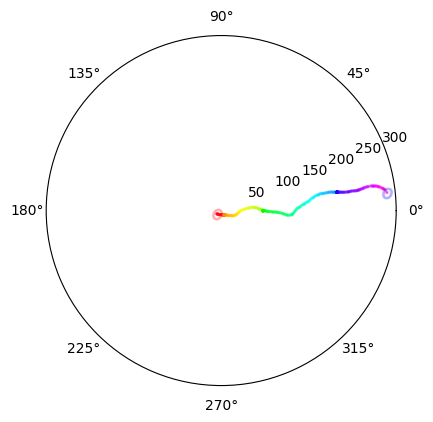

In [5]:
polarPlot_largeDF(antTrackDF, specify ='Eye-capped off-route 1',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Eye-capped on-route 1',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Minus 3m ZV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Plus 3m ZV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='On-route 1 ZV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='On-route 2 ZV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Off-route 1 ZV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='On-route 1B ZV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Route 0m ZV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Unfamiliar FV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Unfamiliar ZV',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Unfamiliar ZV 2',  nest='NewNest', indivcol=True)

In [ ]:
polarPlot_largeDF(antTrackDF, specify ='Unfamiliar ZV 3',  nest='NewNest', indivcol=True)


plot tracks for condition on same plot

In [172]:
def polarPlot_overlayed_largeDF(df, specify=None, nest=None, indivcol = False, save=False):
    # handles the plotting of a large df with multiple seporable vars
    #ids = np.unique(df['ID'])
    if specify is not None:
        df = df[df['Condition']==specify]
    if nest is not None:
        df = df[df['Nest']==nest]
        
    max_len = max(df['frame'])

    df_justfames = df.loc[:, ['ID', 'frame']] 
    #df_justfames['ID'] = df_justfames['ID'].astype("int")
    framelist = df_justfames.groupby(['ID']).max()
    #print(framelist)
    #print(framelist[0][0])
    min_len = framelist.min()
    
    print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
    print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")
    
    # I want the dynamic colour to be related to the condition. so do i need to split the df into condition type. then take the max len.
    conditions = [np.unique(df['Condition'])]
    conditions= conditions[0]
    
    for cond in conditions:
        print(cond)
        df_touse = df[df['Condition']== str(cond)]
        #print(np.unique([type(i) for i in df_touse['ID']]))
        
        max_len = max(df_touse['frame'])
        df_touse['ID'] = df_touse['ID'].astype(str)
        ids = np.unique(df_touse['ID'])
        
    
        #print(ids)
        #for x in ids:    
        #new_df = df_touse[df_touse['ID']== x] # *
        #filename = df_touse['Nest']
        #print("number of frames: ", len(new_df['frame']))
        #if indivcol:
        #    max_len = max(new_df['frame'])
        #print("max frames ", new_df['frame'], new_df['Condition'], x)
        create_Overlayed_polar_plot2(df_touse, max_len, title=f"{np.unique(df_touse['Nest'])} {np.unique(df_touse['Condition'])}", save=save) #  {np.unique(df_touse['ID'])} {(max(new_df['frame'])/25)/60:.2f}  {max(new_df['frame'])/25} seconds    = 
        # frames per 25s    =  {int(np.floor(((max(df_touse['frame'])/25)%3600)/60))} : {((max(df_touse['frame'])/25)%3600)%60:.2f}  m:s  \n {max(df_touse['frame'])} 
        

In [121]:
"""def create_Overlayed_polar_plot(df_coordinates, max_len, title:str, pindex='frame', save=False, xname='x', yname='y', bkgrnd=None, step =10, foodcentered =False):
    from explorationplots import seyiheading_from_d
    from AT_plots import cart2pola
    # takes in a pandas df
    # max_len is the max length of all df to be plotted. used to visually see the time taken- time from frames
    # convert data from df series to np.array for plotting
    fig = plt.figure(figsize=(10, 10)) #10, 10
    ax1 = fig.add_subplot(221)
    ax2 = fig.add_subplot(222,projection='polar')
    alphaval = 0.2

    ids = np.unique(df_coordinates['ID'])
    longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    max_r = 0
    
    if bkgrnd is not None:
        implot = ax1.imshow(bkgrnd)

    for id in ids:
        newdf = df_coordinates[df_coordinates['ID']== id]
        df_len = len(newdf)
        
        
        _x = np.array(newdf[xname])
        _y =  np.array(newdf[yname])
        dx_ = newdf[xname].diff(periods=1)
        dy_ = newdf[yname].diff(periods=1)
        seyi_head_deg =[] 
        for (dx, dy) in zip(dx_, dy_):
            seyi_head_deg.append(seyiheading_from_d(dx,
                                       dy,
                                       offset=90))
        seyi_head_degp90 = [d+90 for d in seyi_head_deg]
        seyi_head_rad = np.deg2rad(seyi_head_degp90)
        final_heading_list.append(seyi_head_rad[-1])
    
        # before polar conversion, need to set data relative to food at center.
        # get food pos
        # Convert to polar coordinates
        if foodcentered:
            newx = np.array(newdf['new_x'])
            newy = np.array(newdf['new_y'])
            theta, r = cart2pola(newx, newy)
        else:
            theta, r = cart2pola(_x, _y)
        if r[-1] > max_r:
            max_r = r[-1]
        #corn_head_deg = []
        #for t in theta:
        #    corn_head_deg.append(rel2Nest(t, offset=90))
        #corn_head_rad = np.deg2rad(corn_head_deg)
    
       
            
        scatter1 = ax1.scatter(_x, _y, alpha=alphaval,s= 2, c=range(df_len), vmin=0, vmax=max_len, cmap="gist_rainbow") #gist_rainbow
        ax1.grid(False)
        
        
        # Plot the points
        scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2,c=range(df_len), vmin=0, vmax=max_len, cmap="gist_rainbow") #nipy_spectral
        ax2.grid(False)
        #ax1.quiver(_x[::step],  # x
        #    _y[::step],      # y
        #    np.sin(seyi_head_rad[::step]),    # U [0]
        #    np.cos(seyi_head_rad[::step]),  # V
        #    df_coordinates[pindex][::step],   # C
        #    ec='k', cmap="gist_rainbow")# Seyi
    
        # quivers for polar plot
        #ax2.quiver(theta[::step],  # x
        #    r[::step],      # y
        #    dy_[::step],    # U [0]
        #    dx_[::step],  # V
        #    df_coordinates[pindex][::step],   # C
        #    ec='k', cmap="ocean")# headings_end[:] headings_end[:]
        #ax2.set_ylim(min(r),max(r)+10)
    
        # plot final pos
        ax1.scatter(_x[-1], _y[-1], alpha=alphaval, marker='$o$',s= 60, c= 'blue') 
        ax2.scatter(theta[-1], r[-1], alpha=alphaval, marker='$o$',s= 60, c= 'blue') 
        # start point pos
        ax1.scatter(_x[0], _y[0], alpha=alphaval, marker='$o$',s= 60, c= 'red') 
        ax2.scatter(theta[0], r[0], alpha=alphaval, marker='$o$',s= 60, c= 'red') 

        if df_len > longestdf['length']: # ensure that legend is created once
            longestdf['length'] = df_len
            longestdf['scat_ele'] = scatter2.legend_elements()
            
    print(f"final headings:  {final_heading_list}")
    
    rayleigh_ans = astro.rayleightest(final_heading_list) # astro rayleightest wants radians
    if rayleigh_ans <= 0.05:
    
        mean_theta = np.array(final_heading_list)
        mean_heading_theta = scipy.stats.circmean(mean_theta) # circ mean wants radians
        print(f"mean theta type {type(mean_heading_theta)} mean: {mean_heading_theta}")
    

        ax2.scatter(mean_heading_theta, max_r, alpha=0.4, marker='$o$',s= 60, c= 'k') 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.sin(mean_heading_theta),    # U [0]
            np.cos(max_r),  # V
            ec='k', scale=1)# headings_end[:] headings_end[:]
    
    #plt.plot([], [], 'o', label=f'Mean: {mean_heading_theta}', color='red')
    
    ax1.plot(mean_heading_theta)
    ax1.plot(rayleigh_ans)
    
    legend2 = fig.legend(*longestdf['scat_ele'],
                loc="upper right", title="frames")
    fig.add_artist(legend2)
    fig.suptitle(title)
        #ax.set_title(title)
    if save == True:
        plt.savefig(title)
        #f"{np.unique(df_coordinates['Nest'])}_{np.unique(df_coordinates['Condition'])}_{np.unique(df_coordinates['ID'])}"
    
    plt.show()"""

WIGWAM nest:
% homing=-180+55;%off-route 1
% homing=180-115;%on-route 2
% homing=180-102;%unfamiliar

%homing direction for different releases at NEW nest:
% homing=-180+33;%off-route 1
% homing=-180-(14+144);%on-route 2
% homing=-180-49;%unfamiliar 1
% homing=-180+88;%unfamiliar 2
% homing=-180+82;%unfamiliar 3

In [436]:
print(antTrackDF.keys())
print("")
print(np.unique(antTrackDF['Condition']))
print("")
print(np.unique(antTrackDF['Nest']))
print("")
print(np.unique(antTrackDF[(antTrackDF['Nest']== 'Wigwam')]['Condition']))

Index(['Date', 'ID', 'frame', 'x', 'y', 'Nest', 'Condition'], dtype='object')

['Eye-capped off-route 1' 'Eye-capped on-route 1' 'Minus 3m ZV'
 'Off-route 1 ZV' 'On-route 1 ZV' 'On-route 1B ZV' 'On-route 2 ZV'
 'Plus 3m ZV' 'Route 0m ZV' 'Unfamiliar FV' 'Unfamiliar ZV'
 'Unfamiliar ZV 2' 'Unfamiliar ZV 3']

['NewNest' 'Wigwam']

['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']


In [548]:
def match_nestCondition_treeDir(nest:str, condition:str):
    tree_dir = None
    
    if nest.lower() =='wigwam' or nest.lower() == 'nest1':
        if condition.lower() == 'off-route 1 ZV':
            tree_dir = -180+55
        elif condition.lower == 'on-route 2 ZV':#'minus 3m zv'
            tree_dir = -180 -115
        elif condition.lower() == 'unfamiliar ZV' or condition.lower() == 'unfamiliar FV':
            tree_dir = 180 -102
        else:
            print(f"Condition not recognised! {condition} {nest}")
            pass
    elif nest.lower() == 'newnest' or nest.lower() == 'nest2':
        if condition.lower() == 'off-route 1':
            tree_dir = -180 +33
        elif condition.lower() == 'on-route 2':
            tree_dir = 180 -(14_144)
        elif condition.lower() == 'unfamiliar ZV' or condition.lower() == 'unfamiliar FV':
            tree_dir =-180-49
        elif condition.lower() == 'unfamiliar ZV 2' or condition.lower() == 'unfamiliar FV 2':
            tree_dir =-180+88
        elif condition.lower() == 'unfamiliar ZV 3' or condition.lower() == 'unfamiliar FV 3':
            tree_dir =-180+82
        else:
            print(f"Condition not recognised! {condition} {nest}")
    
    else:
        #print("Sorry, the condition or nest Combo you are looking for, are not in our library. tree set to 0")
        tree_dir = None

    return tree_dir

In [552]:
def tree_pos(newdf):
    cond = np.unique(newdf['Condition']).tolist()
    cond = [str(c) for c in cond]
    nest = np.unique(newdf['Nest']).tolist()
    nests = []
    tree_dirs = []
    tree_dir = None
    
    i = 0
    if len(nest)>=2:
        print(f"TOO MANY NESTS ASSOCIATED WITH THIS ID")
        if len(cond) >= 2:
            print(f"TOO MANY CONDITIONS ASSOCIATED WITH THIS ID")
            i = max(len(nest), len(cond))
    for k in range(i+1):
        n = str(nest[i])
        c = str(cond[i])
        tree_dir = match_nestCondition_treeDir(n, c)
        tree_dirs.append(tree_dir)
        
    #print(tree_dirs)
    return tree_dirs
    
            

In [553]:
antTrackDF.keys()
k = antTrackDF.loc[:,'frame']
#print(k)

In [554]:
# print(np.unique(antTrackDF[(antTrackDF['Nest']== 'Wigwam')]['Condition']))
sampledf = antTrackDF[antTrackDF['Nest'] == 'Wigwam']
#[str(id) for id in antTrackDF.loc[:,'ID']]
antTrackDF['ID'] = antTrackDF['ID'].astype('str')
ids = np.unique(antTrackDF['ID'])
for id in ids:
    newdf = antTrackDF[antTrackDF['ID'] == id]
    treepos = tree_pos(newdf)
    if treepos != 0:
        print(treepos)

Condition not recognised! Minus 3m ZV NewNest
[None]
Condition not recognised! Minus 3m ZV NewNest
[None]
Condition not recognised! Minus 3m ZV NewNest
[None]
Condition not recognised! Minus 3m ZV NewNest
[None]
Condition not recognised! Route 0m ZV NewNest
[None]
Condition not recognised! Route 0m ZV NewNest
[None]
Condition not recognised! Route 0m ZV NewNest
[None]
Condition not recognised! Route 0m ZV NewNest
[None]
Condition not recognised! Plus 3m ZV NewNest
[None]
Condition not recognised! Plus 3m ZV NewNest
[None]
Condition not recognised! Plus 3m ZV NewNest
[None]
Condition not recognised! Plus 3m ZV NewNest
[None]
Condition not recognised! Minus 3m ZV NewNest
[None]
Condition not recognised! Minus 3m ZV NewNest
[None]
Condition not recognised! Minus 3m ZV NewNest
[None]
Condition not recognised! Minus 3m ZV NewNest
[None]
Condition not recognised! Route 0m ZV NewNest
[None]
Condition not recognised! Route 0m ZV NewNest
[None]
Condition not recognised! Route 0m ZV NewNest
[Non

IndexError: list index out of range

In [ ]:

def create_Overlayed_polar_plot2(df_coordinates, max_len, title:str, pindex='frame', save =False, xname='x', yname='y', bkgrnd=None, step =10, foodcentered =False):
    # create plot base
    fig = plt.figure(figsize=(10, 10)) #10, 10
    #ax2 = fig.add_subplot(222,projection='polar')
    ax2 = fig.add_subplot(211, projection='polar')
    ax3 = fig.add_subplot(212, projection='polar')
    alphaval = 0.2

    ids = np.unique(df_coordinates['ID'])
    longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    cart_final_heading_list = []
    max_r = 0
    
    if bkgrnd is not None:
        implot = ax1.imshow(bkgrnd)

    for id in ids:
        newdf = df_coordinates[df_coordinates['ID']== id]
        df_len = len(newdf)
        
        _x = np.array(newdf[xname])
        _y =  np.array(newdf[yname])
        dx_ = newdf[xname].diff(periods=1)
        dy_ = newdf[yname].diff(periods=1)
        
        if foodcentered:
            newx = np.array(newdf['new_x'])
            newy = np.array(newdf['new_y'])
            theta, r = cart2pola(newx, newy)

        theta, r = cart2pola(_x, _y)
        final_heading_list.append(theta[-1])
        
        if r[-1] > max_r:
            max_r = r[-1]
        
        # Plot the points
        scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2,c=range(df_len), vmin=0, vmax=max_len, cmap="winter") #nipy_spectral gist_rainbow
        ax2.grid(False)
        
    
        # plot final pos
        ax2.scatter(theta[-1], r[-1], alpha=alphaval, marker='$o$',s= 60, c= 'blue') 
        ax2.scatter(theta[0], r[0], alpha=alphaval, marker='$o$',s= 60, c= 'red') 

        if df_len > longestdf['length']: # ensure that legend is created once
            longestdf['length'] = df_len
            longestdf['scat_ele'] = scatter2.legend_elements()

    #print(f"final headings:  {final_heading_list}")
    histn, histbins = np.histogram(final_heading_list, bins=36)
    histwidths = np.diff(histbins)
    histrad = histn#[rad+2 if rad<=2 else rad for rad in histn]
    #print(f"hist rads {histrad} len{len(histrad)}  minus1 {len(histrad)-1}")
    
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array) # astro rayleightest wants radians
    final_heading_listdeg = [np.rad2deg(i) for i in final_heading_list]
    #print(f"len histbins {len(histbins)}  len histrad {len(histrad)}   widths {len(histwidths)}")
    ax3.bar(histbins[:-1], histrad, align='edge', width= histwidths, bottom=8)
    if rayleigh_ans <= 0.05:
        mean_heading_theta = scipy.stats.circmean(final_heading_array) # circ mean wants radians
        var_heading_theta = scipy.stats.circvar(final_heading_array)
        std_heading_theta = scipy.stats.circstd(final_heading_array)
        #print(f"mean theta type {type(mean_heading_theta)} mean: {mean_heading_theta}")
        print(f" mean head rad {mean_heading_theta}")
        print(f" std head rad {std_heading_theta}")
        print(f" var head rad {var_heading_theta}")
    
        #ax2.scatter(mean_heading_theta, max_r, alpha=0.4, marker='$o$',s= 60, c= 'k') 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta),  # V
            np.sin(mean_heading_theta),    # U [0]
            ec='k', scale=1)# 
        ax3.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta),  # V
            np.sin(mean_heading_theta),    # U [0]
            ec='k', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta+var_heading_theta),  # V
            np.sin(mean_heading_theta+var_heading_theta),    # U [0]
            color='yellow', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta-var_heading_theta),  # V
            np.sin(mean_heading_theta-var_heading_theta),    # U [0]
            color='yellow', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta+var_heading_theta),  # V
            np.sin(mean_heading_theta+var_heading_theta),    # U [0]
            color='yellow', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta-var_heading_theta),  # V
            np.sin(mean_heading_theta-var_heading_theta),    # U [0]
            color='yellow', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta+std_heading_theta),  # V
            np.sin(mean_heading_theta+std_heading_theta),    # U [0]
            color='orange', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta-std_heading_theta),  # V
            np.sin(mean_heading_theta-std_heading_theta),    # U [0]
            color='orange', scale=1)# 
    ax2.quiver(0,  # x mean_heading_theta
        0,      # y max_r
        np.cos(np.deg2rad(180)),  # V
        np.sin(np.deg2rad(180)),    # U [0]
        color='red', scale=1)# 
    ax3.quiver(0,  # x mean_heading_theta
        0,      # y max_r
        np.cos(np.deg2rad(180)),  # V
        np.sin(np.deg2rad(180)),    # U [0]
        color='red', scale=1)# 
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    ax3.set_yticklabels([])
    ax3.set_xticklabels([])
    #legend2 = fig.legend(*longestdf['scat_ele'],
    #            loc="upper right", title="frames")
    #fig.add_artist(legend2)
    #fig.suptitle(title)
    #fig.axes(False)

    if save == True:
        plt.savefig(fname='/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/'+title+"_hist"+".png", format='png')
    
    plt.show()

In [379]:
np.unique(antTrackDF['Condition'])

array(['Eye-capped off-route 1', 'Eye-capped on-route 1', 'Minus 3m ZV',
       'Off-route 1 ZV', 'On-route 1 ZV', 'On-route 1B ZV',
       'On-route 2 ZV', 'Plus 3m ZV', 'Route 0m ZV', 'Unfamiliar FV',
       'Unfamiliar ZV', 'Unfamiliar ZV 2', 'Unfamiliar ZV 3'],
      dtype=object)

In [372]:
pwd

'/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks'

## new nest

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 291 frames    Slowest Ant: 9296 frames
Fastest Ant: 11.64 seconds    Slowest Ant: 371.84 seconds
Eye-capped off-route 1
 mean head rad 3.4841771593781403
 std head rad 1.545195251800671
 var head rad 0.6969368814418673


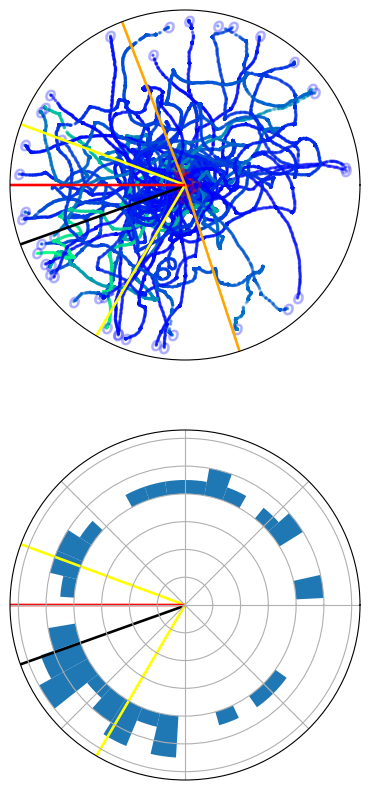

In [423]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Eye-capped off-route 1',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 499 frames    Slowest Ant: 44213 frames
Fastest Ant: 19.96 seconds    Slowest Ant: 1768.52 seconds
Eye-capped on-route 1
 mean head rad 1.472376107486356
 std head rad 1.34944811260418
 var head rad 0.5976790413455575


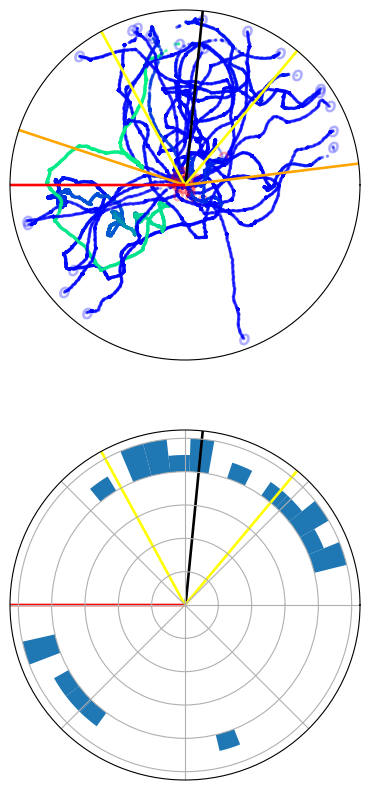

In [424]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Eye-capped on-route 1',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 270 frames    Slowest Ant: 12104 frames
Fastest Ant: 10.8 seconds    Slowest Ant: 484.16 seconds
Minus 3m ZV
 mean head rad 2.4299644181555053
 std head rad 1.1374468303175347
 var head rad 0.4763295191959356


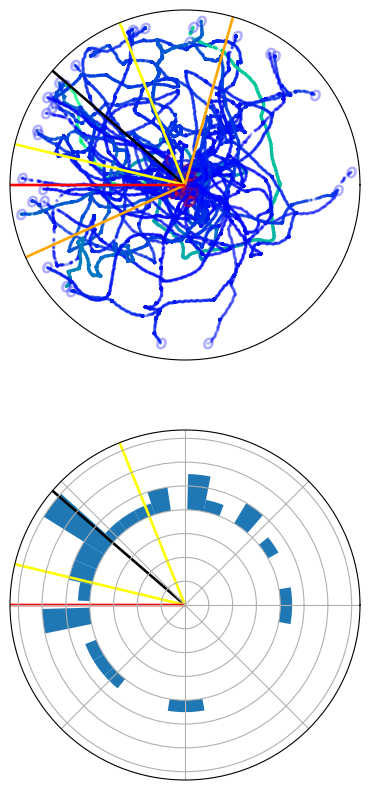

In [425]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Minus 3m ZV',  nest='NewNest', indivcol=True, save=True)


/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 82 frames    Slowest Ant: 6839 frames
Fastest Ant: 3.28 seconds    Slowest Ant: 273.56 seconds
Off-route 1 ZV
 mean head rad 3.245009571729025
 std head rad 1.31249371093189
 var head rad 0.5773960684568725


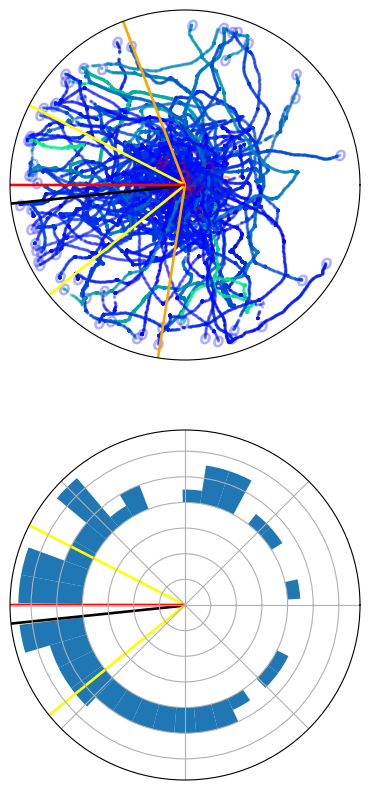

In [426]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Off-route 1 ZV',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 38 frames    Slowest Ant: 6496 frames
Fastest Ant: 1.52 seconds    Slowest Ant: 259.84 seconds
On-route 1 ZV
 mean head rad 3.6694501532952133
 std head rad 1.720252712976681
 var head rad 0.7722791399802209


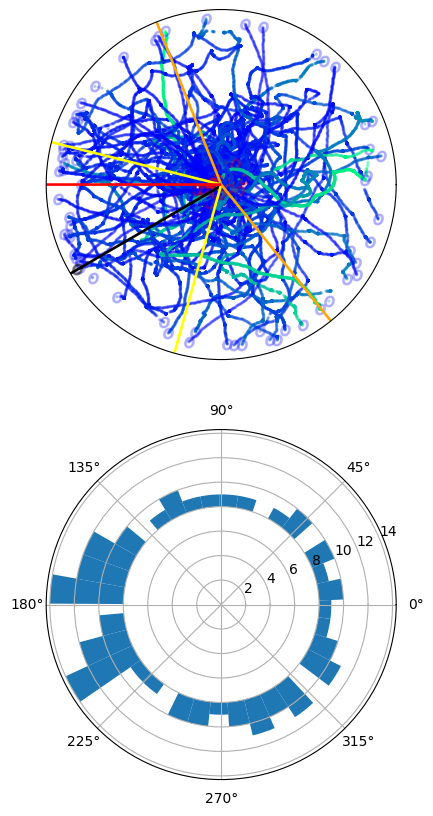

In [413]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='On-route 1 ZV',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 311 frames    Slowest Ant: 17921 frames
Fastest Ant: 12.44 seconds    Slowest Ant: 716.84 seconds
On-route 1B ZV
 mean head rad 2.96819169833212
 std head rad 1.0883843736018481
 var head rad 0.44694082300840565


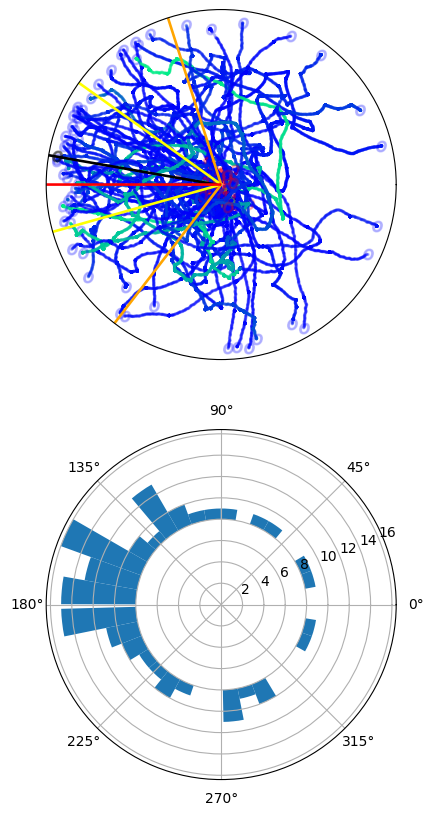

In [414]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='On-route 1B ZV',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 230 frames    Slowest Ant: 29049 frames
Fastest Ant: 9.2 seconds    Slowest Ant: 1161.96 seconds
On-route 2 ZV


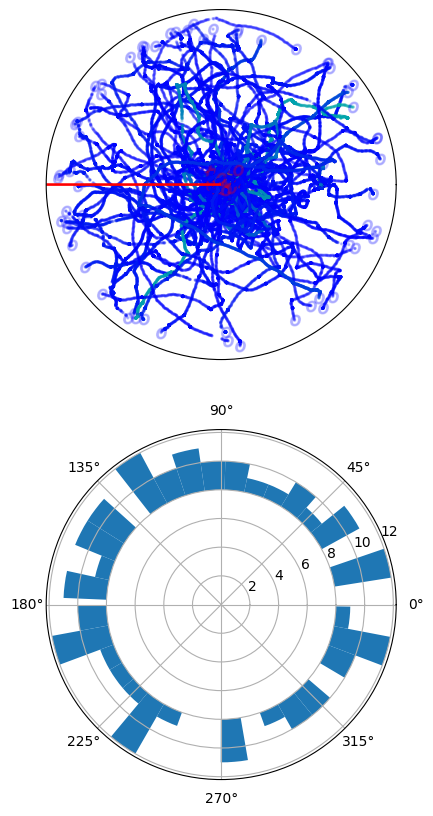

In [415]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='On-route 2 ZV',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 255 frames    Slowest Ant: 44680 frames
Fastest Ant: 10.2 seconds    Slowest Ant: 1787.2 seconds
Plus 3m ZV


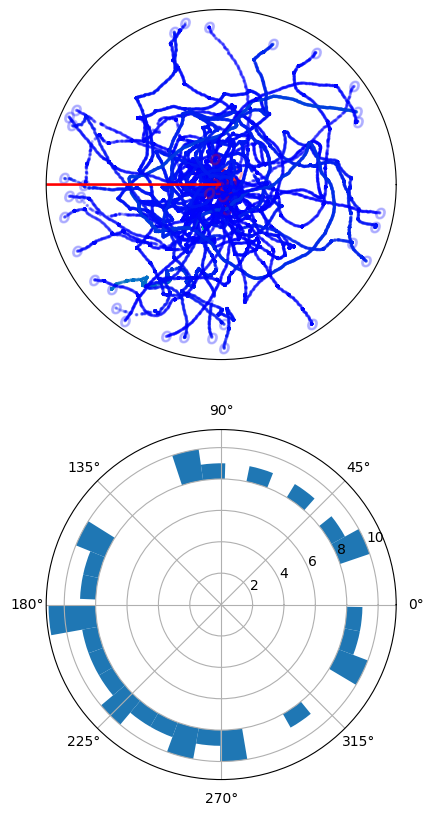

In [416]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Plus 3m ZV',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 269 frames    Slowest Ant: 32597 frames
Fastest Ant: 10.76 seconds    Slowest Ant: 1303.88 seconds
Route 0m ZV
 mean head rad 2.296316962737769
 std head rad 1.3466359088082498
 var head rad 0.5961509604963449


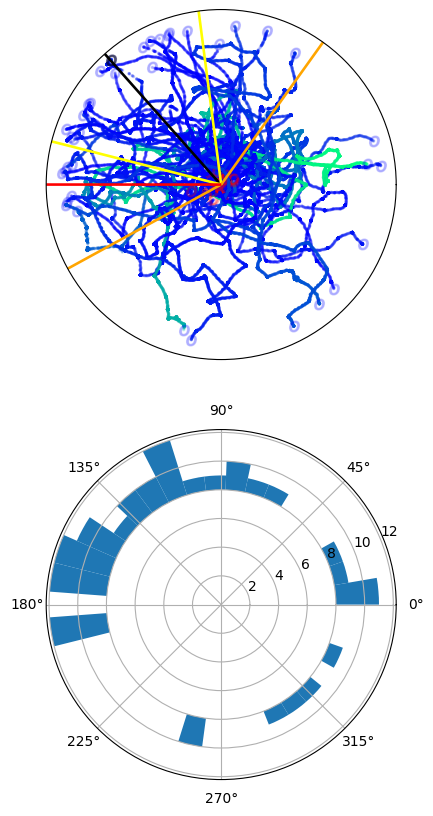

In [417]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Route 0m ZV',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 285 frames    Slowest Ant: 28822 frames
Fastest Ant: 11.4 seconds    Slowest Ant: 1152.88 seconds
Unfamiliar FV


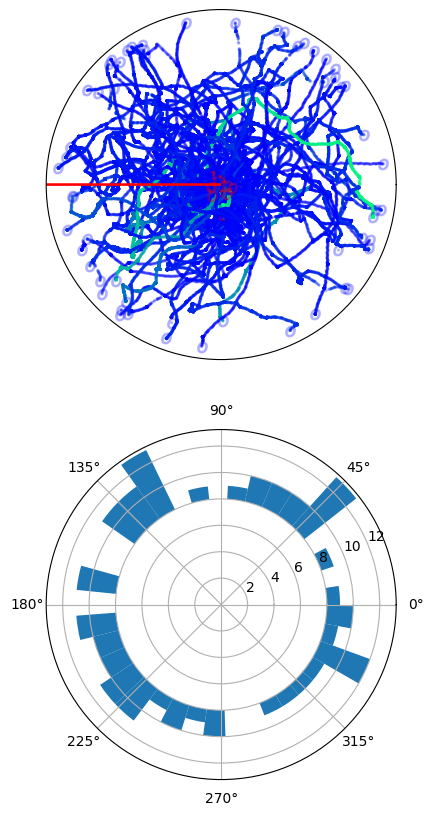

In [418]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Unfamiliar FV',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 213 frames    Slowest Ant: 44022 frames
Fastest Ant: 8.52 seconds    Slowest Ant: 1760.88 seconds
Unfamiliar ZV
 mean head rad 1.9553081695008536
 std head rad 1.62974186542012
 var head rad 0.7350010125513026


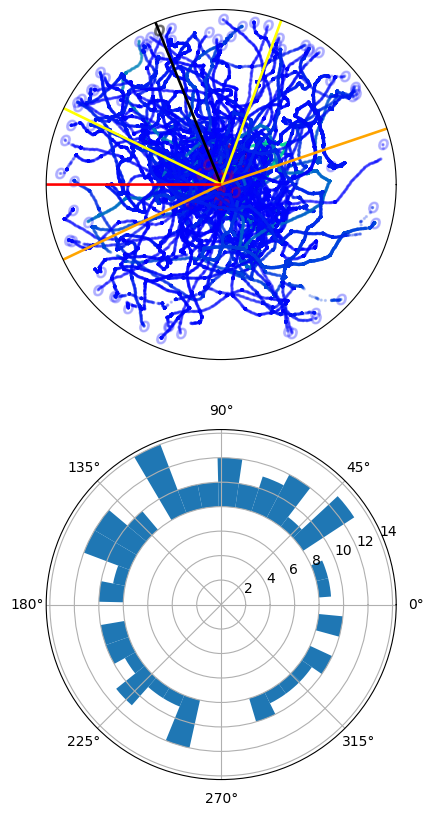

In [419]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Unfamiliar ZV',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 326 frames    Slowest Ant: 36153 frames
Fastest Ant: 13.04 seconds    Slowest Ant: 1446.12 seconds
Unfamiliar ZV 2


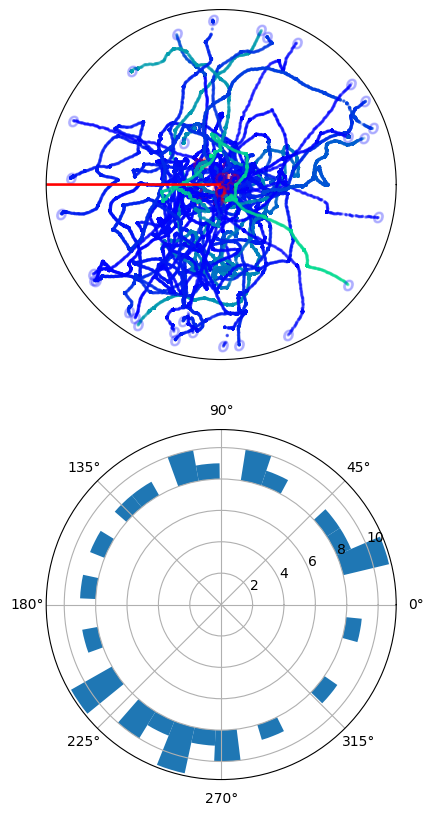

In [420]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Unfamiliar ZV 2',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 286 frames    Slowest Ant: 30358 frames
Fastest Ant: 11.44 seconds    Slowest Ant: 1214.32 seconds
Unfamiliar ZV 3


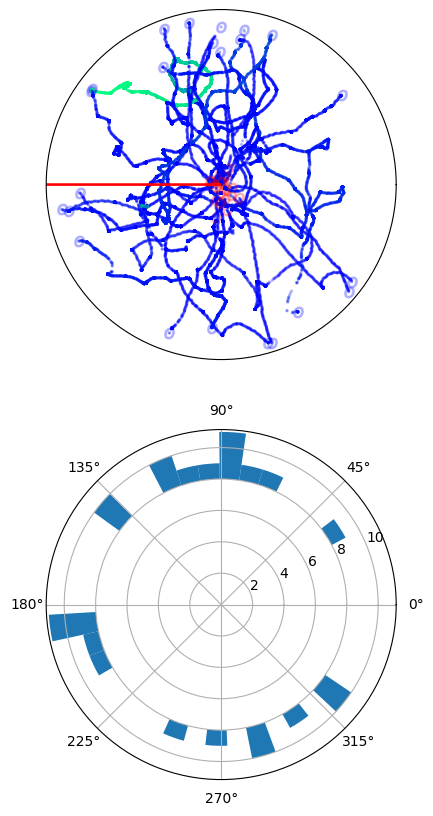

In [421]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Unfamiliar ZV 3',  nest='NewNest', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 286 frames    Slowest Ant: 30358 frames
Fastest Ant: 11.44 seconds    Slowest Ant: 1214.32 seconds
Unfamiliar ZV 3


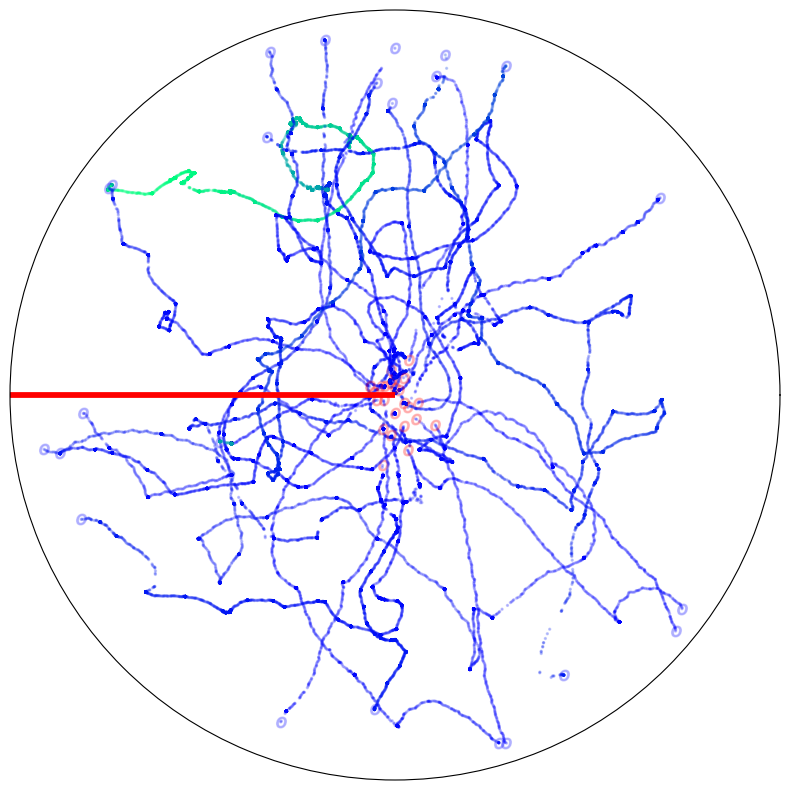

In [339]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Unfamiliar ZV 3',  nest='NewNest', indivcol=True)


/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 499 frames    Slowest Ant: 44213 frames
Fastest Ant: 19.96 seconds    Slowest Ant: 1768.52 seconds
Eye-capped on-route 1
 mean head rad 1.472376107486356
 std head rad 1.34944811260418
 var head rad 0.5976790413455575


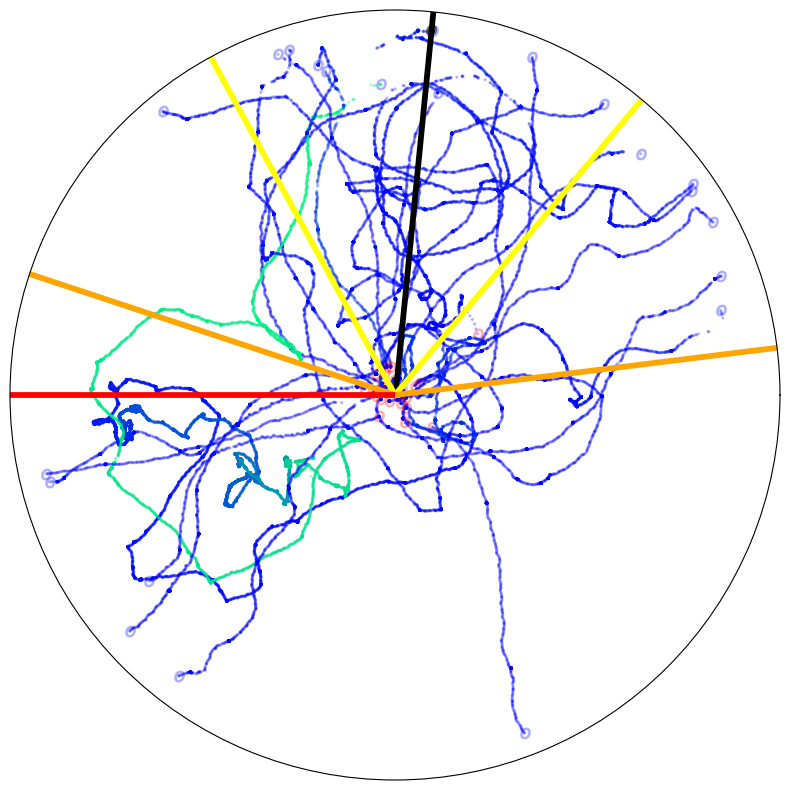

In [340]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Eye-capped on-route 1',  nest='NewNest', indivcol=True)


/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 38 frames    Slowest Ant: 6496 frames
Fastest Ant: 1.52 seconds    Slowest Ant: 259.84 seconds
On-route 1 ZV
 mean head rad 3.6694501532952133
 std head rad 1.720252712976681
 var head rad 0.7722791399802209


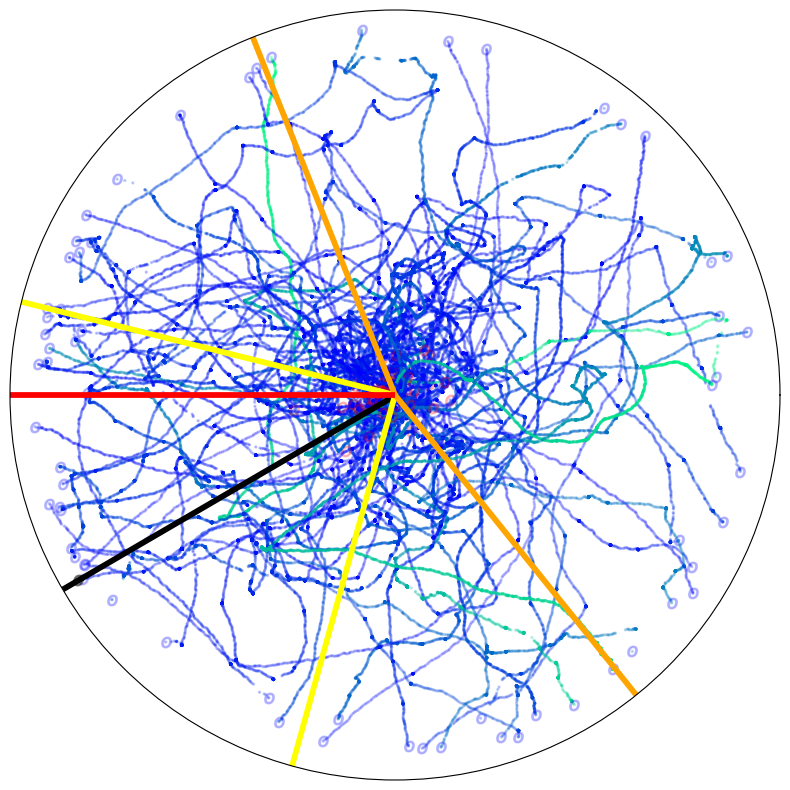

In [341]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='On-route 1 ZV',  nest='NewNest', indivcol=True)

In [342]:
np.unique(antTrackDF['Condition'])

array(['Eye-capped off-route 1', 'Eye-capped on-route 1', 'Minus 3m ZV',
       'Off-route 1 ZV', 'On-route 1 ZV', 'On-route 1B ZV',
       'On-route 2 ZV', 'Plus 3m ZV', 'Route 0m ZV', 'Unfamiliar FV',
       'Unfamiliar ZV', 'Unfamiliar ZV 2', 'Unfamiliar ZV 3'],
      dtype=object)

## wigwam

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 174 frames    Slowest Ant: 12089 frames
Fastest Ant: 6.96 seconds    Slowest Ant: 483.56 seconds
Off-route 1 ZV
 mean head rad 3.277099795554471
 std head rad 1.3910734332638197
 var head rad 0.6199842760743968


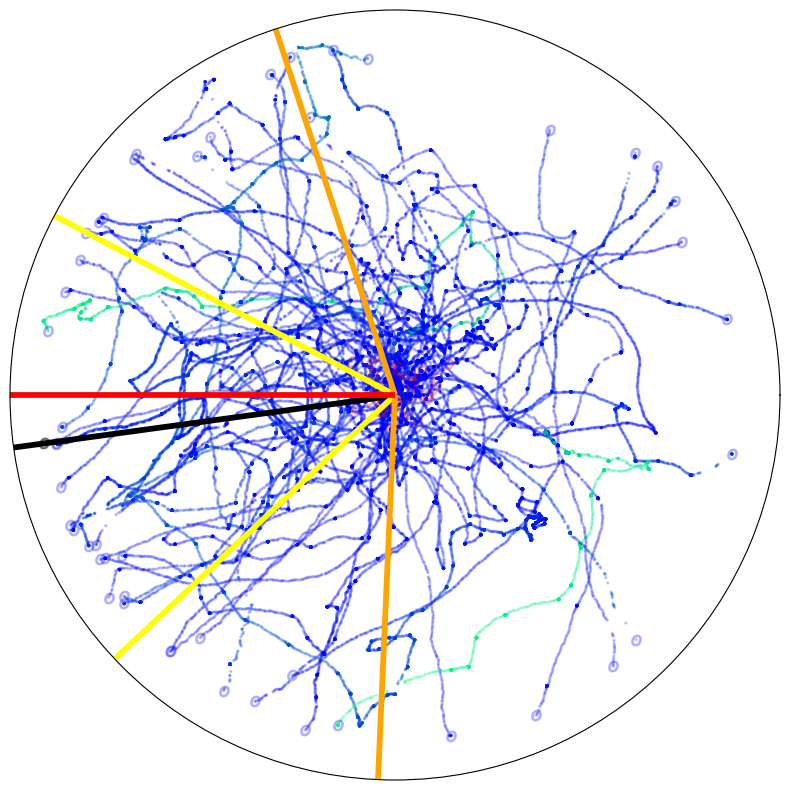

In [343]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Off-route 1 ZV',  nest='Wigwam', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 153 frames    Slowest Ant: 12269 frames
Fastest Ant: 6.12 seconds    Slowest Ant: 490.76 seconds
On-route 1 ZV
 mean head rad 3.1998305922579475
 std head rad 1.346066223531637
 var head rad 0.5958410909259327


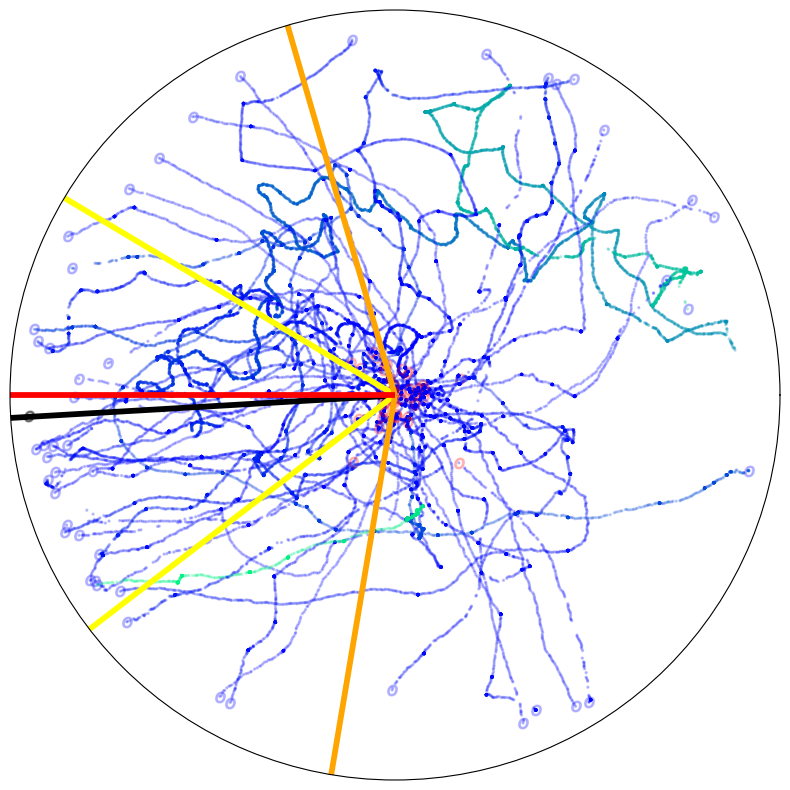

In [344]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='On-route 1 ZV',  nest='Wigwam', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 148 frames    Slowest Ant: 8380 frames
Fastest Ant: 5.92 seconds    Slowest Ant: 335.2 seconds
On-route 2 ZV
 mean head rad 1.1968813529368278
 std head rad 1.5923161940383588
 var head rad 0.7185316949736744


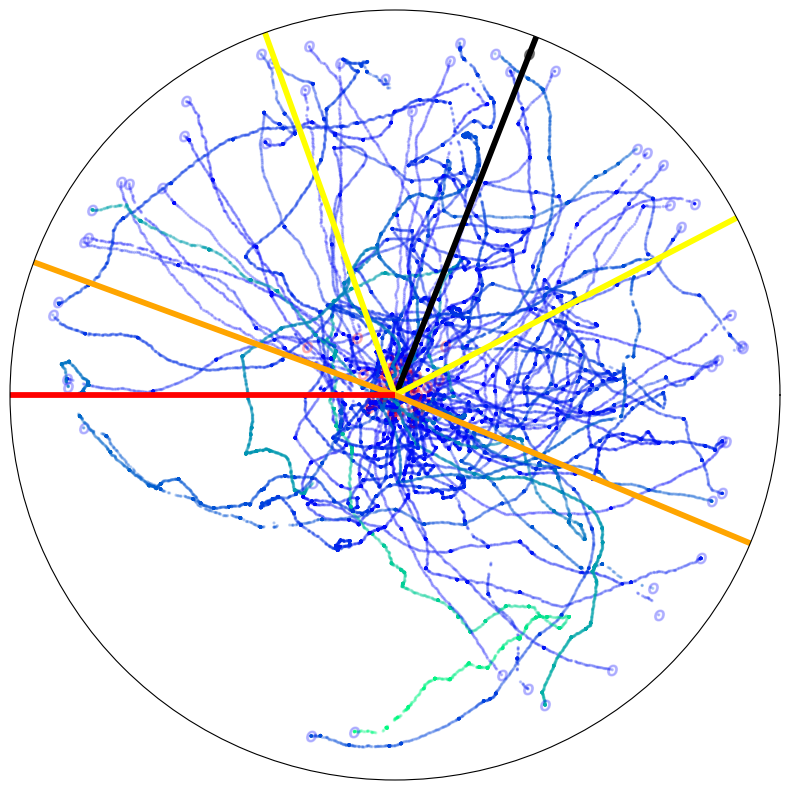

In [345]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='On-route 2 ZV',  nest='Wigwam', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 163 frames    Slowest Ant: 15839 frames
Fastest Ant: 6.52 seconds    Slowest Ant: 633.56 seconds
Unfamiliar FV


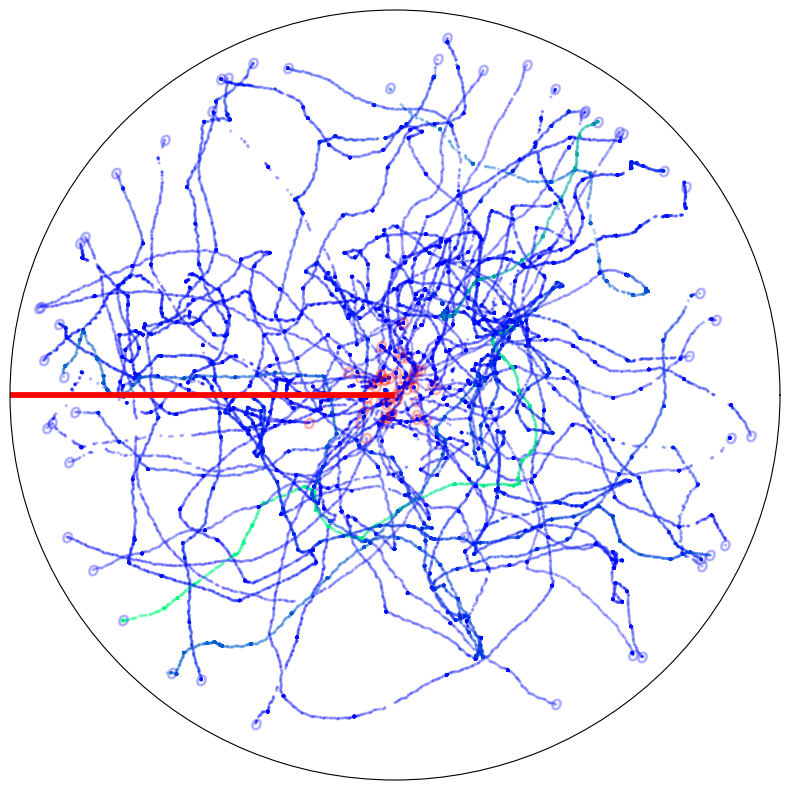

In [346]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Unfamiliar FV',  nest='Wigwam', indivcol=True, save=True)

/tmp/ipykernel_43266/2632257651.py:18: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_43266/2632257651.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Fastest Ant: 179 frames    Slowest Ant: 13183 frames
Fastest Ant: 7.16 seconds    Slowest Ant: 527.32 seconds
Unfamiliar ZV
 mean head rad 1.6507214808638273
 std head rad 1.6066635615749656
 var head rad 0.7249174102515163


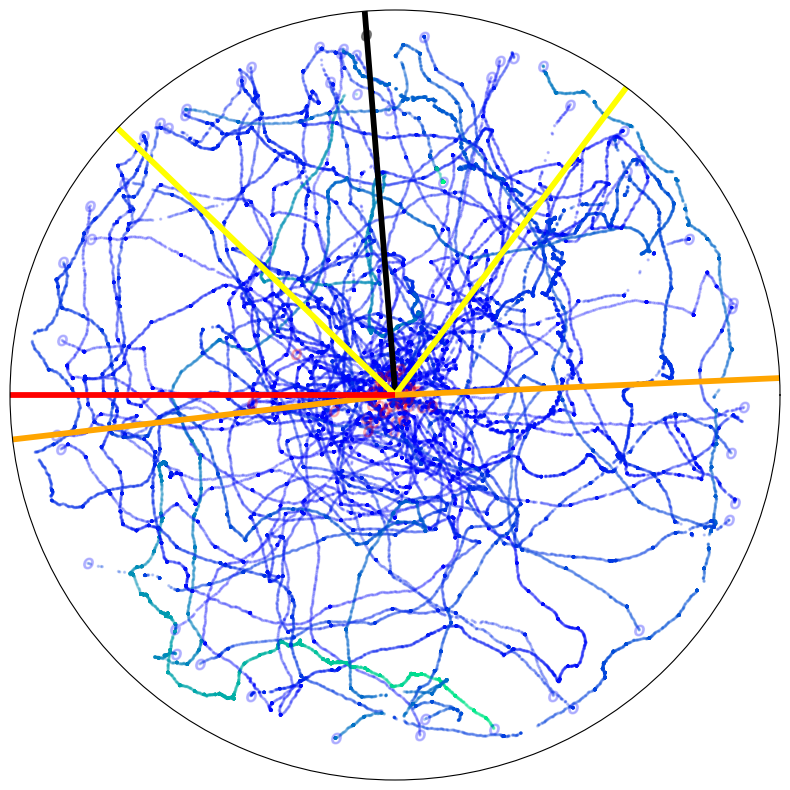

In [347]:
polarPlot_overlayed_largeDF(antTrackDF, specify ='Unfamiliar ZV',  nest='Wigwam', indivcol=True, save=True)

Circ historgrams

In [ ]:
#example code
def circ_hist(df, specify=None, nest=None):
    if specify is not None:
        newdf = df[df['Condition']==specify]
    if nest is not None:
        newdf = newdf[newdf['Nest']==nest]
            
    # create plot base
    fig = plt.figure(figsize=(10, 10)) #10, 10
    #ax2 = fig.add_subplot(222,projection='polar')
    ax2 = fig.add_subplot(projection='polar')
    alphaval = 0.2
    
    ids = np.unique(df_coordinates['ID'])
    longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    cart_final_heading_list = []
    max_r = 0
    
    ax2.bar(newdf[''],)
    #for id in ids:
    #    newdf = newdf[newdf['ID']== id]
    #    df_len = len(newdf)